<a href="https://colab.research.google.com/github/icosahedron31/Walmart-Sales/blob/main/TFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wandb onnx -Uq

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Imports**

In [3]:
!pip install pytorch_forecasting -q

In [4]:


import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch
import json


In [5]:
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer

**WandB**

In [6]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: tdola23 (tdola23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

**Data Processing**

In [7]:
train_df = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/train_processed.csv")
val_df = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/val_processed.csv")

In [8]:
val_df.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'Week', 'Month',
       'Year', 'Quarter', 'holiday_name', 'lag_1', 'lag_2', 'lag_4', 'lag_52',
       'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4',
       'rolling_mean_52'],
      dtype='object')

**Preprocessing**

In [9]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class PickColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_keep=None):
        self.columns_to_keep = [
            'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
            'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
            'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size'
            ,'Week', 'Month', 'Year', 'Quarter', 'holiday_name'
        ]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.columns_to_keep].copy()

In [10]:
column_picker = PickColumns()
X_train = column_picker.fit_transform(train_df)
X_val = column_picker.transform(val_df)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332778 entries, 0 to 332777
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         332778 non-null  int64  
 1   Dept          332778 non-null  int64  
 2   Date          332778 non-null  object 
 3   Weekly_Sales  332778 non-null  float64
 4   IsHoliday     332778 non-null  bool   
 5   Temperature   332778 non-null  float64
 6   Fuel_Price    332778 non-null  float64
 7   MarkDown1     332778 non-null  float64
 8   MarkDown2     332778 non-null  float64
 9   MarkDown3     332778 non-null  float64
 10  MarkDown4     332778 non-null  float64
 11  MarkDown5     332778 non-null  float64
 12  CPI           332778 non-null  float64
 13  Unemployment  332778 non-null  float64
 14  Type          332778 non-null  object 
 15  Size          332778 non-null  int64  
 16  Week          332778 non-null  int64  
 17  Month         332778 non-null  int64  
 18  Year

In [11]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class ConvertToCategorical(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns or ['Store', 'Dept', 'IsHoliday', 'Type',  'holiday_name']

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = list(self.columns)

        missing = set(self.columns_) - set(X.columns)
        if missing:
            raise ValueError(f"Missing expected columns: {missing}")

        self.categories_ = {
            col: pd.Series(X[col].astype(str).unique()).sort_values().tolist()
            for col in self.columns_
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.columns_:
            X[col] = pd.Categorical(X[col].astype(str), categories=self.categories_[col])
        return X

In [12]:
class DateToTimeIdx(BaseEstimator, TransformerMixin):

    def __init__(self, date_col='Date', time_idx_col='time_idx'):
        self.date_col = date_col
        self.time_idx_col = time_idx_col

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        dates = pd.to_datetime(X[self.date_col])
        self.min_date_ = dates.min()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])

        delta_days = (X[self.date_col] - self.min_date_).dt.days
        X[self.time_idx_col] = (delta_days // 7).astype(int)

        return X


In [13]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('pick_columns', PickColumns()),
    ('to_categorical', ConvertToCategorical()),
    ('Date_processor', DateToTimeIdx())
])
X_train = pipeline.fit_transform(train_df)
X_val = pipeline.transform(val_df)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332778 entries, 0 to 332777
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         332778 non-null  category      
 1   Dept          332778 non-null  category      
 2   Date          332778 non-null  datetime64[ns]
 3   Weekly_Sales  332778 non-null  float64       
 4   IsHoliday     332778 non-null  category      
 5   Temperature   332778 non-null  float64       
 6   Fuel_Price    332778 non-null  float64       
 7   MarkDown1     332778 non-null  float64       
 8   MarkDown2     332778 non-null  float64       
 9   MarkDown3     332778 non-null  float64       
 10  MarkDown4     332778 non-null  float64       
 11  MarkDown5     332778 non-null  float64       
 12  CPI           332778 non-null  float64       
 13  Unemployment  332778 non-null  float64       
 14  Type          332778 non-null  category      
 15  Size          332

**Creating Dataset**

In [14]:
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer

max_encoder_length = 52
max_prediction_length = 35

training = TimeSeriesDataSet(
    X_train,
    time_idx="time_idx",
    target="Weekly_Sales",
    group_ids=["Store", "Dept"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,


    static_categoricals=["Store", "Dept", "Type"],
    static_reals=["Size"],

    time_varying_known_categoricals=["IsHoliday", "holiday_name"],
    time_varying_known_reals=[
        "time_idx", "Year", "Month", "Week", "Quarter",
        "Temperature", "Fuel_Price", "CPI", "Unemployment",
        "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    ],


    time_varying_unknown_reals=["Weekly_Sales"],

    target_normalizer=GroupNormalizer(
        groups=["Store", "Dept"]
    ),

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,

    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    pd.concat([X_train, X_val], axis=0).reset_index(drop=True),
    predict=True,
    stop_randomization=True,
)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1861: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 291 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__Store': '1', '__group_id__Dept': '51'}, {'__group_id__Store': '1', '__group_id__Dept': '77'}, {'__group_id__Store': '1', '__group_id__Dept': '78'}, {'__group_id__Store': '10', '__group_id__Dept': '51'}, {'__group_id__Store': '10', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '48'}, {'__group_id__Store': '11', '__group_id__Dept': '50'}, {'__group_id__Store': '11', '__group_id__Dept': '51'}, {'__group_id__Store': '11', '__group_id__Dept': '77'}, {'__group_id__Store': '11', '__group_id__Dept': '78'}]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/tim

In [15]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332778 entries, 0 to 332777
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         332778 non-null  category      
 1   Dept          332778 non-null  category      
 2   Date          332778 non-null  datetime64[ns]
 3   Weekly_Sales  332778 non-null  float64       
 4   IsHoliday     332778 non-null  category      
 5   Temperature   332778 non-null  float64       
 6   Fuel_Price    332778 non-null  float64       
 7   MarkDown1     332778 non-null  float64       
 8   MarkDown2     332778 non-null  float64       
 9   MarkDown3     332778 non-null  float64       
 10  MarkDown4     332778 non-null  float64       
 11  MarkDown5     332778 non-null  float64       
 12  CPI           332778 non-null  float64       
 13  Unemployment  332778 non-null  float64       
 14  Type          332778 non-null  category      
 15  Size          332

In [16]:
train_loader = training.to_dataloader(train=True, batch_size=64, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

**Loss**

In [17]:
# WMAE metric
import numpy as np

def WMAE(y_true, y_pred, is_holiday):
    is_holiday_bool = is_holiday.astype(str).str.lower().isin(["true"])
    weights = np.where(is_holiday_bool, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

**Baseline**

In [18]:
from pytorch_forecasting import Baseline

baseline_predictions = Baseline().predict(
    val_loader,
    return_x=True,
    return_y=True,
    return_index=True,
)

y_pred = baseline_predictions.output.cpu()
y_true = baseline_predictions.y[0].cpu()
index_df = baseline_predictions.index  # already a dataframe with Store, Dept, time_idx per row

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

In [19]:
y_pred.shape, y_true.shape, index_df.shape

(torch.Size([2947, 35]), torch.Size([2947, 35]), (2947, 3))

In [20]:
import numpy as np
import pandas as pd

# y_pred, y_true shape: (num_samples, prediction_length)
pred_len = y_pred.shape[1]

# Repeat each index row pred_len times, and add offset 0..pred_len-1 to time_idx
index_expanded = index_df.loc[index_df.index.repeat(pred_len)].reset_index(drop=True)
index_expanded["time_idx"] = (
    index_expanded["time_idx"].values
    + np.tile(np.arange(pred_len), len(index_df))
)

# Flatten predictions/targets to match row-by-row
index_expanded["y_pred"] = y_pred.numpy().flatten()
index_expanded["y_true"] = y_true.numpy().flatten()
full_df = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)

# Now merge with your full dataset on the keys + time_idx
print(index_expanded.shape)
merged = index_expanded.merge(
    full_df,
    on=["Store", "Dept", "time_idx"],
    how="inner"   # or "inner" if you only want rows that have predictions
)
merged.info()

(103145, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100795 entries, 0 to 100794
Data columns (total 24 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   time_idx      100795 non-null  int64         
 1   Store         100795 non-null  object        
 2   Dept          100795 non-null  object        
 3   y_pred        100795 non-null  float32       
 4   y_true        100795 non-null  float32       
 5   Date          100795 non-null  datetime64[ns]
 6   Weekly_Sales  100795 non-null  float64       
 7   IsHoliday     100795 non-null  category      
 8   Temperature   100795 non-null  float64       
 9   Fuel_Price    100795 non-null  float64       
 10  MarkDown1     100795 non-null  float64       
 11  MarkDown2     100795 non-null  float64       
 12  MarkDown3     100795 non-null  float64       
 13  MarkDown4     100795 non-null  float64       
 14  MarkDown5     100795 non-null  float64       
 15  CPI  

In [21]:
print(merged["y_true"].isna().sum())
print(merged["y_pred"].isna().sum())
print(merged["IsHoliday"].isna().sum())
print(len(merged))

0
0
0
100795


In [22]:
wmae = WMAE(merged["y_true"], merged["y_pred"], merged["IsHoliday"])
print(f"WMAE: {wmae}")

WMAE: 2801.958783269697


**Training**

In [23]:
from pytorch_forecasting.metrics import MAE
pl.seed_everything(42)
trainer = pl.Trainer(
    accelerator="cuda",
    # clipping gradients is a hyperparameter and important to prevent divergance
    # of the gradient for recurrent neural networks
    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    # not meaningful for finding the learning rate but otherwise very important
    learning_rate=0.001,
    hidden_size=64,  # most important hyperparameter apart from learning rate
    # number of attention heads. Set to up to 4 for large datasets
    attention_head_size=1,
    dropout=0.1,  # between 0.1 and 0.3 are good values
    hidden_continuous_size=8,  # set to <= hidden_size
    loss=MAE(),
    optimizer="ranger",
    # reduce learning rate if no improvement in validation loss after x epochs
    reduce_on_plateau_patience=1000,
)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during c

In [24]:
!pip install pytorch_optimizer

In [25]:
import torch

_original_load = torch.load
def _patched_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return _original_load(*args, **kwargs)
torch.load = _patched_load

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/utilities.py:73: `max_epochs` was not set. Setting it to 1000 epochs. To train without an epoch limit, set `max_epochs=-1`.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.
/usr/local/lib/python3.12/dist-packages/lightning/p

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO: Restoring states from the checkpoint path at /content/.lr_find_a9f46b96-d06b-46c0-94f6-181cb9a485b1.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_a9f46b96-d06b-46c0-94f6-181cb9a485b1.ckpt
INFO: Restored all states from the checkpoint at /content/.lr_find_a9f46b96-d06b-46c0-94f6-181cb9a485b1.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_a9f46b96-d06b-46c0-94f6-181cb9a485b1.ckpt
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO: Learning rate set to 2.290867652767773e-06
INFO:lightning.pytorch.tuner.lr_finder:Learning rate set to 2.290867652767773e-06


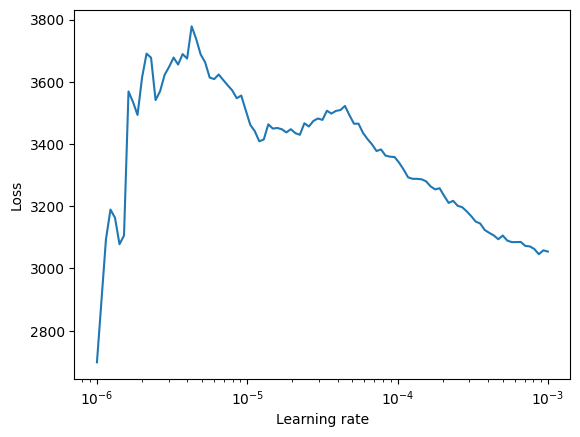

In [26]:
from lightning.pytorch.tuner import Tuner
from pytorch_forecasting.data.encoders import GroupNormalizer

torch.serialization.add_safe_globals([GroupNormalizer])

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
    max_lr=1e-3,
    min_lr=1e-6,
)

#print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True)
fig.show()

**HyperParameter Tuning**

In [27]:
!pip install optuna optuna-integration[wandb] wandb

In [28]:
import pickle
import inspect

import wandb
from optuna.integration.wandb import WeightsAndBiasesCallback
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters


wandb_kwargs = {
    "project": "walmart-sales-forecasting",
    "group": "TFT",
}
wandbc = WeightsAndBiasesCallback(wandb_kwargs=wandb_kwargs, as_multirun=True)


sig = inspect.signature(optimize_hyperparameters)
print(sig)

(train_dataloaders: torch.utils.data.dataloader.DataLoader, val_dataloaders: torch.utils.data.dataloader.DataLoader, model_path: str, max_epochs: int = 20, n_trials: int = 100, timeout: float = 28800.0, gradient_clip_val_range: tuple[float, float] = (0.01, 100.0), hidden_size_range: tuple[int, int] = (16, 265), hidden_continuous_size_range: tuple[int, int] = (8, 64), attention_head_size_range: tuple[int, int] = (1, 4), dropout_range: tuple[float, float] = (0.1, 0.3), learning_rate_range: tuple[float, float] = (1e-05, 1.0), use_learning_rate_finder: bool = True, trainer_kwargs: dict[str, typing.Any] = {}, log_dir: str = 'lightning_logs', study=None, verbose: int | bool = None, pruner=None, **kwargs)


/tmp/ipykernel_12409/4217774539.py:13: FutureWarning: WeightsAndBiasesCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  wandbc = WeightsAndBiasesCallback(wandb_kwargs=wandb_kwargs, as_multirun=True)


In [29]:
!pip install optuna statsmodels optuna-integration

In [30]:
import optuna

_original_optimize = optuna.study.Study.optimize

def _optimize_with_wandb(self, func, *args, **kwargs):
    existing_callbacks = kwargs.get("callbacks", [])
    kwargs["callbacks"] = existing_callbacks + [wandbc]
    return _original_optimize(self, func, *args, **kwargs)

optuna.study.Study.optimize = _optimize_with_wandb

study = optimize_hyperparameters(
    train_loader,
    val_loader,
    model_path="optuna_test",
    n_trials=30,
    max_epochs=10,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 4),
    learning_rate_range=(0.00001, 0.01),
    dropout_range=(0.1, 0.3),
    trainer_kwargs=dict(limit_train_batches=30),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,
)

# restore original behavior afterward
optuna.study.Study.optimize = _original_optimize

/usr/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.pytorch_lightning` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.pytorch_lightning` instead.
  return _bootstrap._gcd_import(name[level:], package, level)
[I 2026-07-06 11:20:34,359] A new study created in memory with name: no-name-aa2b7bef-c5df-470a-a9bc-190af508f530
/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/models/temporal_fusion_transformer/tuning.py:176: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gradient_clip_val = trial.suggest_loguniform(
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:l

attention_head_size,▁
dropout,▁
gradient_clip_val,▁
hidden_continuous_size,▁
hidden_size,▁
learning_rate,▁
trial_number,▁
value,▁
attention_head_size,1
dropout,0.12343
gradient_clip_val,0.11488


/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/models/temporal_fusion_transformer/tuning.py:176: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  gradient_clip_val = trial.suggest_loguniform(
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.o

attention_head_size,▁
dropout,▁
gradient_clip_val,▁
hidden_continuous_size,▁
hidden_size,▁
learning_rate,▁
trial_number,▁
value,▁
attention_head_size,2
dropout,0.12189
gradient_clip_val,0.01728


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[I 2026-07-06 11:24:54,466] Trial 2 pruned. Trial was pruned at epoch 1.


...

attention_head_size,▁
dropout,▁
gradient_clip_val,▁
hidden_continuous_size,▁
hidden_size,▁
learning_rate,▁
trial_number,▁
value,▁
attention_head_size,2
dropout,0.10171
gradient_clip_val,0.31537


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[I 2026-07-06 11:42:54,390] Trial 28 pruned. Trial was pruned at epoch 1.


attention_head_size,▁
dropout,▁
gradient_clip_val,▁
hidden_continuous_size,▁
hidden_size,▁
learning_rate,▁
trial_number,▁
value,▁
attention_head_size,1
dropout,0.14436
gradient_clip_val,0.71772


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
[I 2026-07-06 11:43:25,683] Trial 29 pruned. Trial was pruned at epoch 1.


attention_head_size,▁
dropout,▁
gradient_clip_val,▁
hidden_continuous_size,▁
hidden_size,▁
learning_rate,▁
trial_number,▁
value,▁
attention_head_size,2
dropout,0.1207
gradient_clip_val,0.12689
